# Monoclonal Antibody (mAb) Process Optimization

This notebook demonstrates an **end-to-end mAb manufacturing process** using difflow_bio unit operations, with gradient-based optimization of key process parameters.

## Process Overview

```
Fed-Batch         Disc-Stack        Protein A       UF/DF
Bioreactor   ->   Centrifuge   ->   Capture    ->   Formulation
(Upstream)        (Harvest)         (Capture)       (Final)
```

We will optimize:
1. Bioreactor feeding strategy
2. Chromatography load volume
3. Final formulation concentration

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, value_and_grad
import matplotlib.pyplot as plt
import optax  # JAX optimization library

jax.config.update("jax_enable_x64", True)

from difflow_bio import (
    # Upstream
    FedBatchBioreactor, FedBatchParams, monod_kinetics,
    # Downstream
    DiscStackCentrifuge, DiscStackParams,
    ProteinAChromatography, ProteinAParams,
    TFF,
)
from difflow import make_stream, get_flows

## 1. Define Process Units

Set up each unit operation with realistic parameters for mAb production.

In [2]:
# ============================================================
# BIOREACTOR - Fed-batch CHO cell culture
# ============================================================
bioreactor_params = FedBatchParams(
    V0=1000.0,              # 1000 L initial volume
    Y_xs=0.4,               # Cell yield on glucose
    kinetic_fn=monod_kinetics,
    kinetic_params={
        "mu_max": jnp.array(0.03),  # CHO cells: ~0.03 h^-1
        "K_s": jnp.array(0.1),
    },
    k_d=0.002,              # Low death rate
    alpha=0.05,             # mAb is secreted during growth (q_p = alpha*mu)
    beta=0.002,             # Some constitutive secretion
)

bioreactor = FedBatchBioreactor(bioreactor_params)

# ============================================================
# CENTRIFUGE - Disc-stack for cell removal
# ============================================================
centrifuge_params = DiscStackParams(
    n_discs=100,
    r_outer=0.15,
    r_inner=0.05,
    rpm=7000,
    efficiency=0.80,
    cell_species="cells",
)
centrifuge = DiscStackCentrifuge(centrifuge_params)

# ============================================================
# PROTEIN A CHROMATOGRAPHY - Capture step
# ============================================================
# Fed-batch grows from 1000L to ~30,000L, producing ~50 kg mAb
# Column sized for 80% capacity utilization at max production:
#   50 kg / (40 g/L * 0.8) = 1562 L → use 1600 L column
proa_params = ProteinAParams(
    column_volume=1600.0,   # 1600 L column for fed-batch production
    q_max=40.0,             # 40 g/L binding capacity
    K_d=0.05,
    target_species="product",
    yield_factor=0.92,
    impurity_clearance={
        "cells": 4.0,
        "HCP": 2.5,         # Host cell proteins
    },
)
proa = ProteinAChromatography(proa_params)

# ============================================================
# TFF - Final concentration and formulation
# ============================================================
tff = TFF(
    membrane_area=10.0,     # 10 m^2
    MWCO=30.0,
    rejection={"product": 0.999, "excipient": 0.0},
)

print("Process units initialized.")

Process units initialized.


## 2. Define the End-to-End Process

Create a function that runs the entire process and returns the final product mass.

In [3]:
def run_mab_process(params):
    """
    Run complete mAb manufacturing process.
    
    Args:
        params: dict with optimization parameters:
            - feed_rate_scale: Scaling factor for feed rate
            - culture_time: Duration of cell culture (hours)
            - proa_load_cycles: Number of chromatography cycles
            - final_CF: Final concentration factor
    
    Returns:
        product_mass: Final mAb mass (g)
        info: Dictionary with intermediate results
    """
    feed_rate_scale = params['feed_rate_scale']
    culture_time = params['culture_time']
    final_CF = params['final_CF']
    
    # ========== UPSTREAM: Fed-Batch Bioreactor ==========
    def feed_rate(t):
        """Exponential feed profile."""
        F0 = 5.0 * feed_rate_scale  # L/h base rate
        mu_set = 0.02  # Target growth rate
        return F0 * jnp.exp(mu_set * t)
    
    outlet_bio, info_bio = bioreactor(
        X0=0.5,        # Initial viable cell density (g/L)
        S0=5.0,        # Initial glucose (g/L)
        P0=0.0,        # No initial product
        t_final=culture_time,
        feed_rate_fn=feed_rate,
        S_feed=400.0,  # Concentrated glucose feed
        n_steps=100,
    )
    
    # Convert bioreactor output to harvest stream
    # Product is in g, need to add impurities
    total_product = outlet_bio['F_product']
    total_cells = outlet_bio['F_cells']
    
    # Estimate HCP based on cell mass (typical: 10% of cell mass)
    HCP = total_cells * 0.1
    
    harvest = make_stream(
        {
            "cells": total_cells,
            "product": total_product,
            "HCP": HCP,
            "substrate": outlet_bio['F_substrate'],
        },
        T=310.0, P=101325.0
    )
    
    # ========== HARVEST: Centrifugation ==========
    # Total volume from bioreactor
    harvest_volume = info_bio['V_final']
    
    # Flow rate based on processing 8 hours
    Q_cent = harvest_volume / (8.0 * 3600.0)  # m^3/s
    
    concentrate, clarified, info_cent = centrifuge(
        harvest,
        Q=Q_cent,
        concentrate_fraction=0.05,
    )
    
    # ========== CAPTURE: Protein A ==========
    # Load volume = clarified harvest volume
    clarified_volume = harvest_volume * 0.95  # 95% goes to clarified
    
    (proa_product, proa_waste), info_proa = proa(
        clarified,
        load_volume=clarified_volume,
        feed_volume=clarified_volume,
    )
    
    # ========== FORMULATION: TFF ==========
    # Concentrate to final formulation
    (final_product, _), info_tff = tff.concentrate(
        proa_product,
        concentration_factor=final_CF,
    )
    
    # ========== Calculate Metrics ==========
    final_product_mass = final_product['F_product']
    
    info = {
        'bioreactor': info_bio,
        'centrifuge': info_cent,
        'protein_a': info_proa,
        'tff': info_tff,
        'harvest_volume': harvest_volume,
        'harvest_titer': total_product / harvest_volume,  # g/L
        'overall_yield': final_product_mass / total_product,
    }
    
    return final_product_mass, info

print("Process function defined.")

Process function defined.


## 3. Run Baseline Process

In [4]:
# Baseline parameters
baseline_params = {
    'feed_rate_scale': jnp.array(1.0),
    'culture_time': jnp.array(240.0),   # 10 days
    'final_CF': jnp.array(10.0),
}

product_mass, info = run_mab_process(baseline_params)

print("Baseline Process Results:")
print("="*50)
print(f"\nUpstream (Bioreactor):")
print(f"  Final volume: {float(info['harvest_volume']):.0f} L")
print(f"  Harvest titer: {float(info['harvest_titer'])*1000:.2f} mg/L")
print(f"  Cell concentration: {float(info['bioreactor']['X_final']):.2f} g/L")

print(f"\nDownstream:")
print(f"  Centrifuge cell recovery: {float(info['centrifuge']['cell_recovery'])*100:.1f}%")
print(f"  Protein A yield: {float(info['protein_a']['yield'])*100:.1f}%")
print(f"  Protein A purity: {float(info['protein_a']['purity'])*100:.1f}%")

print(f"\nOverall:")
print(f"  Final product mass: {float(product_mass):.1f} g")
print(f"  Overall yield: {float(info['overall_yield'])*100:.1f}%")

Baseline Process Results:

Upstream (Bioreactor):
  Final volume: 31128 L
  Harvest titer: 1651.53 mg/L
  Cell concentration: 13.23 g/L

Downstream:
  Centrifuge cell recovery: 4.5%
  Protein A yield: 92.0%
  Protein A purity: 0.4%

Overall:
  Final product mass: 44827.3 g
  Overall yield: 87.2%


## 4. Gradient-Based Optimization

Since the entire process is differentiable, we can use gradient descent to optimize process parameters!

In [5]:
def objective(params):
    """Objective: maximize product mass (minimize negative)."""
    product_mass, _ = run_mab_process(params)
    return -product_mass  # Negative for minimization

# Compute gradients
grad_fn = jax.grad(objective)

# Initial parameters
params = {
    'feed_rate_scale': jnp.array(0.8),
    'culture_time': jnp.array(200.0),
    'final_CF': jnp.array(8.0),
}

# Compute gradient at initial point
grads = grad_fn(params)
print("Gradients at initial point:")
for key, g in grads.items():
    print(f"  d(product)/d({key}): {float(g):.6f}")

Gradients at initial point:
  d(product)/d(culture_time): -409.785257
  d(product)/d(feed_rate_scale): -72.982951
  d(product)/d(final_CF): 1.823253


In [6]:
# Optimization using optax.adam for better convergence
def optimize_process(initial_params, n_iters=50, learning_rate=0.1):
    """Optimize process parameters using Adam optimizer from optax."""
    params = {k: v.copy() for k, v in initial_params.items()}
    
    # Define parameter bounds
    bounds = {
        'feed_rate_scale': (0.5, 2.0),
        'culture_time': (168.0, 336.0),  # 7-14 days
        'final_CF': (5.0, 20.0),
    }
    
    # Scale factors for different parameters (helps optimizer treat them equally)
    scale_factors = {
        'feed_rate_scale': 0.1,
        'culture_time': 10.0,
        'final_CF': 0.5,
    }
    
    # Create optimizer with gradient clipping for stability
    optimizer = optax.chain(
        optax.clip_by_global_norm(10.0),  # Prevent gradient explosions
        optax.adam(learning_rate=learning_rate),
    )
    opt_state = optimizer.init(params)
    
    history = {
        'product_mass': [],
        'feed_rate_scale': [],
        'culture_time': [],
        'final_CF': [],
    }
    
    for i in range(n_iters):
        # Compute value and gradient
        loss, grads = value_and_grad(objective)(params)
        
        # Scale gradients for better optimization dynamics
        scaled_grads = {k: g * scale_factors[k] for k, g in grads.items()}
        
        # Get updates from optimizer
        updates, opt_state = optimizer.update(scaled_grads, opt_state, params)
        
        # Apply updates
        params = optax.apply_updates(params, updates)
        
        # Clip parameters to bounds
        params = {k: jnp.clip(v, bounds[k][0], bounds[k][1]) 
                  for k, v in params.items()}
        
        # Record history
        history['product_mass'].append(-float(loss))
        history['feed_rate_scale'].append(float(params['feed_rate_scale']))
        history['culture_time'].append(float(params['culture_time']))
        history['final_CF'].append(float(params['final_CF']))
        
        if i % 10 == 0:
            print(f"Iter {i:3d}: product = {-loss:.2f} g")
    
    return params, history

# Run optimization
initial_params = {
    'feed_rate_scale': jnp.array(0.8),
    'culture_time': jnp.array(200.0),
    'final_CF': jnp.array(8.0),
}

print("Optimizing process with optax.adam...\n")
optimized_params, history = optimize_process(initial_params, n_iters=50)

Optimizing process with optax.adam...



Iter   0: product = 14586.03 g


Iter  10: product = 15039.62 g


Iter  20: product = 15475.74 g


Iter  30: product = 15919.42 g


Iter  40: product = 16372.87 g


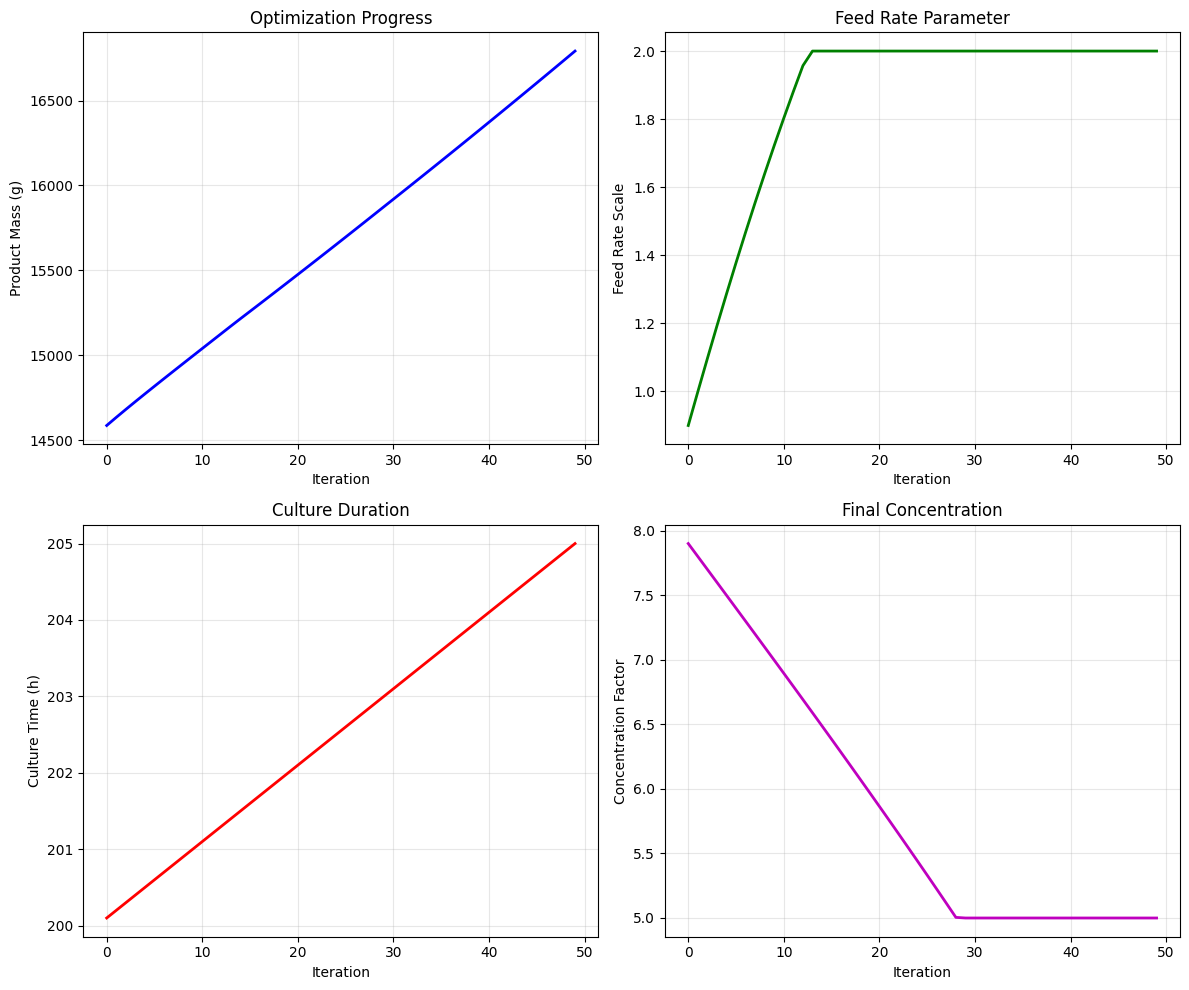

In [7]:
# Plot optimization progress
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(history['product_mass'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Product Mass (g)')
axes[0, 0].set_title('Optimization Progress')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['feed_rate_scale'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Feed Rate Scale')
axes[0, 1].set_title('Feed Rate Parameter')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['culture_time'], 'r-', linewidth=2)
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Culture Time (h)')
axes[1, 0].set_title('Culture Duration')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['final_CF'], 'm-', linewidth=2)
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Concentration Factor')
axes[1, 1].set_title('Final Concentration')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Compare initial vs optimized
print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)

initial_product, _ = run_mab_process(initial_params)
optimized_product, opt_info = run_mab_process(optimized_params)

print(f"\nInitial parameters:")
print(f"  Feed rate scale: {float(initial_params['feed_rate_scale']):.2f}")
print(f"  Culture time: {float(initial_params['culture_time']):.1f} h ({float(initial_params['culture_time'])/24:.1f} days)")
print(f"  Final CF: {float(initial_params['final_CF']):.1f}")
print(f"  -> Product: {float(initial_product):.1f} g")

print(f"\nOptimized parameters:")
print(f"  Feed rate scale: {float(optimized_params['feed_rate_scale']):.2f}")
print(f"  Culture time: {float(optimized_params['culture_time']):.1f} h ({float(optimized_params['culture_time'])/24:.1f} days)")
print(f"  Final CF: {float(optimized_params['final_CF']):.1f}")
print(f"  -> Product: {float(optimized_product):.1f} g")

improvement = (float(optimized_product) - float(initial_product)) / float(initial_product) * 100
print(f"\nImprovement: {improvement:.1f}%")


OPTIMIZATION RESULTS



Initial parameters:
  Feed rate scale: 0.80
  Culture time: 200.0 h (8.3 days)
  Final CF: 8.0
  -> Product: 14586.0 g

Optimized parameters:
  Feed rate scale: 2.00
  Culture time: 205.0 h (8.5 days)
  Final CF: 5.0
  -> Product: 16839.2 g

Improvement: 15.4%


## 5. Sensitivity Analysis

Use gradients to understand which parameters most affect product output.

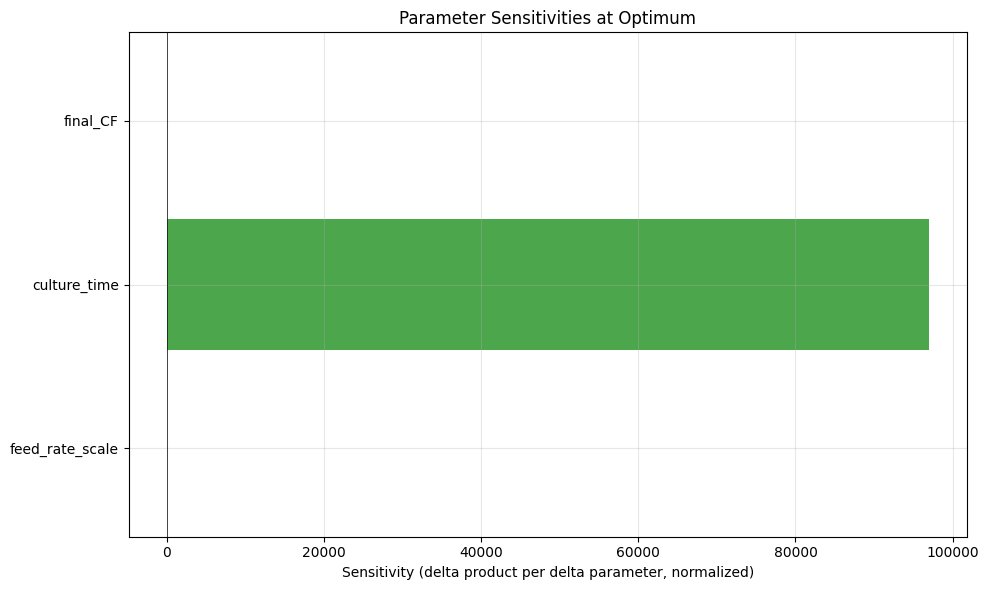


Interpretation:
  Positive sensitivity -> increasing parameter increases product
  At optimum, most sensitivities should be near zero (at bounds) or balanced


In [9]:
# Compute sensitivities at optimized point
grads_opt = grad_fn(optimized_params)

# Normalize by parameter scale for comparison
sensitivities = {
    'feed_rate_scale': -float(grads_opt['feed_rate_scale']) * float(optimized_params['feed_rate_scale']),
    'culture_time': -float(grads_opt['culture_time']) * float(optimized_params['culture_time']),
    'final_CF': -float(grads_opt['final_CF']) * float(optimized_params['final_CF']),
}

# Plot sensitivities
plt.figure(figsize=(10, 6))
params_list = list(sensitivities.keys())
values = [sensitivities[p] for p in params_list]

colors = ['green' if v > 0 else 'red' for v in values]
plt.barh(params_list, values, color=colors, alpha=0.7)
plt.xlabel('Sensitivity (delta product per delta parameter, normalized)')
plt.title('Parameter Sensitivities at Optimum')
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Positive sensitivity -> increasing parameter increases product")
print("  At optimum, most sensitivities should be near zero (at bounds) or balanced")

## 6. Summary

This example demonstrated:

1. **End-to-end process modeling** using difflow_bio unit operations
2. **Automatic differentiation** through the entire manufacturing process
3. **Gradient-based optimization** of process parameters
4. **Sensitivity analysis** using computed gradients

Key advantages of differentiable process models:
- Fast optimization without finite differences
- Exact gradients for sensitivity analysis
- Integration with ML/optimization frameworks (JAX, Optax, etc.)
- Foundation for process control and digital twins